In [1]:
import glob
import torch
import warnings
import numpy as np
import pop_tools
import xesmf as xe
import xarray as xr
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from engression.models import Net
from engression import engression
from dask.distributed import Client
from concurrent.futures import ProcessPoolExecutor

In [2]:
# ------------------------------
# Settings
# ------------------------------

# Set seed
torch.manual_seed(0)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ignore port warning
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

# Load grids
low_grid = pop_tools.get_grid('POP_gx1v7')
low_grid['TAREA'] = low_grid['TAREA'] / 1e4
low_grid['TAREA'].attrs['units'] = 'm^2'

high_grid = xr.open_dataset('/glade/p/cesmdata/cseg/inputdata/share/domains/domain.ocn.tx0.1v2.161014.nc')
high_grid['tarea'] = high_grid['area'] / 1e4
high_grid['tarea'].attrs['units'] = 'm^2'

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 200)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Plotting
cmap = plt.colormaps['Blues']
plt.rcParams["figure.figsize"] = [6, 6]

# Files
low_res_dirs = sorted(glob.glob('/gdex/data/d651030/BHIST/*ihesp-hires*'))
high_res_dirs = sorted(glob.glob('/gdex/data/d651007/*ihesp-hires*'))

low_vars = ['hi', 'Tsfc', 'uvel', 'vvel']
target_var = ['hi']

bbox = {"lon_min": -115, "lon_max": -95, "lat_min": 66, "lat_max": 73}
lon_min = -115 % 360
lon_max = -95 % 360

comp_map = {
    'hi': 'ice',
    'Tsfc': 'ice',
    'uvel': 'ice',
    'vvel': 'ice',
}

# Set up client
client = Client(n_workers=1, threads_per_worker=8, memory_limit='60GB')
print("If on NCAR, copy and paste this link into the Dask Dashboard tab:")
print(client.dashboard_link)
print("\nDevice:", device)

If on NCAR, copy and paste this link into the Dask Dashboard tab:
https://jupyterhub.hpc.ucar.edu/stable/user/skygale/proxy/34597/status

Device: cpu


In [3]:
# ------------------------------
# Set up training & testing data
# ------------------------------
X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_training.nc').X.values
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_training.nc').Y.values
X.shape, Y.shape

((9, 1032, 5, 19, 26), (9, 1032, 1, 70, 201))

In [9]:
# ------------------------------
# Set up regridding
# ------------------------------
TLONG = ((low_grid.TLONG + 180) % 360) - 180

# Mask grids
mask = (
    (TLONG >= bbox["lon_min"]) &
    (TLONG <= bbox["lon_max"]) &
    (low_grid.TLAT >= bbox["lat_min"]) &
    (low_grid.TLAT <= bbox["lat_max"])
)
low_grid_sub = low_grid.where(mask, drop=True)

mask_high = (
    (high_grid.xc >= lon_min) &
    (high_grid.xc <= lon_max) &
    (high_grid.yc >= bbox["lat_min"]) &
    (high_grid.yc <= bbox["lat_max"])
)
high_grid_sub = high_grid.where(mask_high, drop=True)

# Source grid
ds_src = xr.Dataset({
    "lat": (("nlat", "nlon"), low_grid_sub.TLAT.values),
    "lon": (("nlat", "nlon"), TLONG.where(mask, drop=True).values),
})

# Destination grid
ds_dst = xr.Dataset({
    "lat": (("nj", "ni"), high_grid_sub.yc.values),
    "lon": (("nj", "ni"), high_grid_sub.xc.values),
})

# Create regridders
# Continuous
regridder_bilinear = xe.Regridder(
    ds_src,
    ds_dst,
    method="bilinear",
    periodic=False
)

# Land mask
regridder_nearest = xe.Regridder(
    ds_src,
    ds_dst,
    method="nearest_s2d"
)

# ------------------------------
# Interpolation
# ------------------------------
X_interp_list = []

for m in range(X.shape[0]):

    member_channels = []

    # Continuous predictors
    for i in range(5):
        da = xr.DataArray(
            X[m, i],
            dims=("nlat", "nlon")
        )
        da_interp = regridder_bilinear(da)
        member_channels.append(da_interp.values)

    # Land mask (nearest)
    da_land = xr.DataArray(
        X[m, 5],
        dims=("nlat", "nlon")
    )
    land_interp = regridder_nearest(da_land)
    member_channels.append(land_interp.values)

    member_stack = np.stack(member_channels, axis=0)
    X_interp_list.append(member_stack)

X_hr = np.stack(X_interp_list, axis=0)[:, :5]  # drop land channel for now

print("X_hr shape:", X_hr.shape)

X_hr shape: (9, 5, 207, 460)


In [14]:
# Flatten
N_ens, C, H, W = X_hr.shape
X_flat = X_hr.reshape(N_ens, C, -1)
Y_flat = Y.reshape(N_ens, 1, -1)

# Mask
ocean_mask = (high_grid_sub.mask.values == 1)
ocean_flat = ocean_mask.flatten()
X_flat = X_flat[:, :, ocean_flat]
Y_flat = Y_flat[:, :, ocean_flat]

# Split by ensemble member
n_ens = X_flat.shape[0]
C = X_flat.shape[1]

test_member = np.random.choice(n_ens)
train_members = [i for i in range(n_ens) if i != test_member]

print("Test member:", test_member)

# Reshape
X_train_np = (X_flat[train_members].transpose(0, 2, 1).reshape(-1, C))
Y_train_np = (Y_flat[train_members].transpose(0, 2, 1).reshape(-1, 1))
X_test_np = X_flat[test_member].T
Y_test_np = Y_flat[test_member].T

# Standardize (TRAINING STATS ONLY)
X_mean = X_train_np.mean(axis=0)
X_std = X_train_np.std(axis=0)
X_std[X_std == 0] = 1.0
X_train_np = (X_train_np - X_mean) / X_std
X_test_np = (X_test_np - X_mean) / X_std

print("X_train:", X_train_np.shape)
print("Y_train:", Y_train_np.shape)
print("X_test :", X_test_np.shape)
print("Y_test :", Y_test_np.shape)

Test member: 3
X_train: (97840, 5)
Y_train: (97840, 1)
X_test : (12230, 5)
Y_test : (12230, 1)


In [15]:
# Convert to torch and move to GPU
X_train = torch.tensor(X_train_np, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train_np, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_np, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test_np, dtype=torch.float32).to(device)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: torch.Size([97840, 5])
Y_train: torch.Size([97840, 1])
X_test: torch.Size([12230, 5])
Y_test: torch.Size([12230, 1])


In [18]:
# Final checks
print(torch.isnan(X_train).sum())
print(torch.isnan(Y_train).sum())
print(X_train.mean(0))
print(X_train.std(0))

tensor(0)
tensor(0)
tensor([ 1.1977e-07, -4.9906e-09,  1.7467e-08, -2.4953e-09, -6.6126e-08])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [22]:
# Fit an engression model
engressor = engression(
    X_train,
    Y_train,
    lr=0.005,
    num_epochs=500,
    batch_size=2048,
    device=device
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 2048.
[Epoch 1 (0%), batch 47] energy-loss: 0.4654,  E(|Y-Yhat|): 0.8789,  E(|Yhat-Yhat'|): 0.8270
[Epoch 100 (20%), batch 47] energy-loss: 0.3810,  E(|Y-Yhat|): 0.7709,  E(|Yhat-Yhat'|): 0.7799
[Epoch 200 (40%), batch 47] energy-loss: 0.3728,  E(|Y-Yhat|): 0.7507,  E(|Yhat-Yhat'|): 0.7558
[Epoch 300 (60%), batch 47] energy-loss: 0.3726,  E(|Y-Yhat|): 0.7580,  E(|Yhat-Yhat'|): 0.7708
[Epoch 400 (80%), batch 47] energy-loss: 0.3648,  E(|Y-Yhat|): 0.7480,  E(|Yhat-Yhat'|): 0.7664
[Epoch 500 (100%), batch 47] energy-loss: 0.3654,  E(|Y-Yhat|): 0.7375,  E(|Yhat-Yhat'|): 0.7443

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.3232,  E(|Y-Yhat|): 0.6576,  E(|Yhat-Yhat'|): 0.6688

Pre

In [23]:
engressor.summary()

Engression model with
	 number of layers: 2
	 hidden dimensions: 100
	 noise dimensions: 100
	 residual blocks: False
	 number of epochs: 500
	 batch size: 2048
	 learning rate: 0.005
	 standardization: True
	 training mode: False
	 device: cpu

Training loss (original scale):
	 energy-loss: 0.32, 
	E(|Y-Yhat|): 0.66, 
	E(|Yhat-Yhat'|): 0.67


In [28]:
# Evaluation
mse = engressor.eval_loss(X_test, Y_test, loss_type="l2")
print("L2 loss:", mse)
print("RMSE:", mse**0.5)

print(
    "correlation between predicted and true means:",
    engressor.eval_loss(X_test, Y_test, loss_type="cor")
)

L2 loss: 0.8069546222686768
RMSE: 0.898306530238246
correlation between predicted and true means: 0.34430399537086487


In [29]:
# Predictions
Y_pred_test = engressor.predict(X_test)

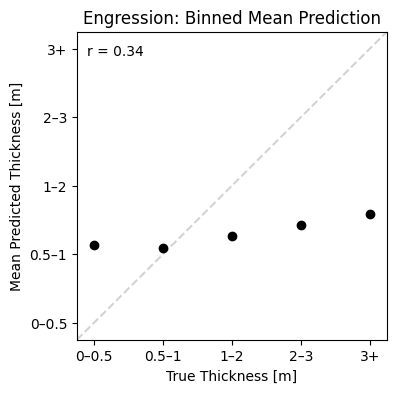

In [87]:
bin_centers = []
mean_pred = []

bins = [0, 0.5, 1.0, 2.0, 3.0, 10]  # meters
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

y_true = Y_test.cpu().numpy().flatten()
y_pred = Y_pred_test.detach().cpu().numpy().flatten()
true_cat = np.digitize(y_true, bins)
pred_cat = np.digitize(y_pred, bins)

for i in range(1, len(bins)):
    mask = (y_true >= bins[i-1]) & (y_true < bins[i])
    if np.sum(mask) > 0:
        bin_centers.append(np.mean(y_true[mask]))
        mean_pred.append(np.mean(y_pred[mask]))

plt.figure(figsize=(4, 4))
plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
plt.scatter(labels, mean_pred, color='k', marker="o", zorder=3)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel("True Thickness [m]")
plt.ylabel("Mean Predicted Thickness [m]")
plt.title("Engression: Binned Mean Prediction")
plt.text(-0.1, 3.9, "r = 0.34")
plt.xlim(-0.25, 4.25)
plt.ylim(-0.25, 4.25)
plt.show()

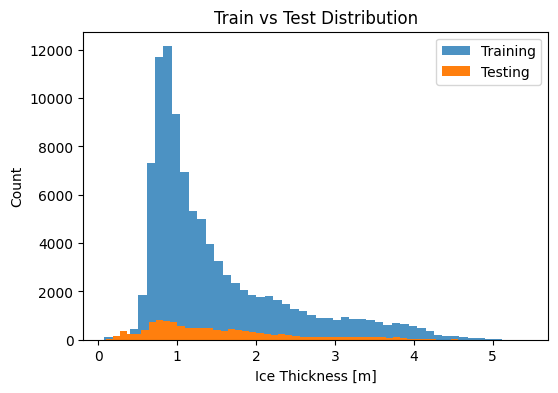

In [46]:
y_train = Y_train.cpu().numpy().flatten()

plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=50, alpha=0.8, label="Training")
plt.hist(y_true, bins=50, label="Testing")
plt.xlabel("Ice Thickness [m]")
plt.ylabel("Count")
plt.legend()
plt.title("Train vs Test Distribution")
plt.show()

In [66]:
# Define model
num_features = X_train.shape[1]
model = Net(num_layer=2, hidden_dim=100, in_dim=num_features).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Training loop (batched)
num_epochs = 500
batch_size = 2048
n_samples = X_train.shape[0]

for epoch in range(num_epochs):
    perm = torch.randperm(n_samples)
    for i in range(0, n_samples, batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = Y_train[idx]

        opt.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        opt.step()

    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            train_loss = criterion(model(X_train), Y_train).item()
            test_loss = criterion(model(X_test), Y_test).item()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Predictions
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

rmse_test = torch.sqrt(criterion(y_pred_test, Y_test))
corr_test = np.corrcoef(Y_test.cpu().numpy().flatten(), y_pred_test.cpu().numpy().flatten())[0, 1]
print("Test RMSE:", rmse_test.item())
print("Test correlation:", corr_test)

Epoch 50/500 | Train Loss: 0.4220 | Test Loss: 0.7027
Epoch 100/500 | Train Loss: 0.4027 | Test Loss: 0.8073
Epoch 150/500 | Train Loss: 0.3791 | Test Loss: 0.8491
Epoch 200/500 | Train Loss: 0.3691 | Test Loss: 0.8336
Epoch 250/500 | Train Loss: 0.3597 | Test Loss: 0.8336
Epoch 300/500 | Train Loss: 0.3571 | Test Loss: 0.8411
Epoch 350/500 | Train Loss: 0.3530 | Test Loss: 0.8713
Epoch 400/500 | Train Loss: 0.3475 | Test Loss: 0.8832
Epoch 450/500 | Train Loss: 0.3533 | Test Loss: 0.9030
Epoch 500/500 | Train Loss: 0.3402 | Test Loss: 0.9396
Test RMSE: 0.9693542718887329
Test correlation: 0.19282535083396346


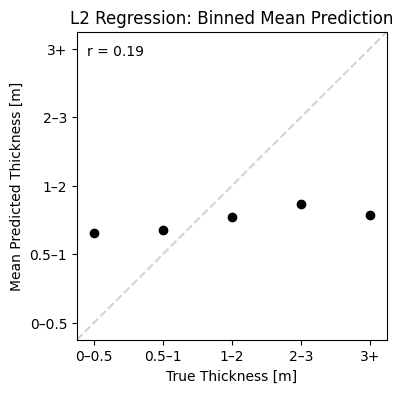

In [89]:
def plot_binned_predictions(y_true, y_pred, bins, labels):
    y_true = y_true.cpu().numpy().flatten()
    y_pred = y_pred.cpu().numpy().flatten()

    # Mean prediction per bin
    y_pred_mean = []
    for i in range(len(bins)-1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.any():
            y_pred_mean.append(y_pred[mask].mean())
        else:
            y_pred_mean.append(np.nan)

    # Plot
    plt.figure(figsize=(4, 4))
    plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
    plt.scatter(labels, y_pred_mean, color="k", marker='o')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel("True Thickness [m]")
    plt.ylabel("Mean Predicted Thickness [m]")
    plt.title("L2 Regression: Binned Mean Prediction")
    plt.text(-0.1, 3.9, "r = 0.19")
    plt.xlim(-0.25, 4.25)
    plt.ylim(-0.25, 4.25)
    plt.show()


bins = [0, 0.5, 1.0, 2.0, 3.0, 10]
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

plot_binned_predictions(Y_test, y_pred_test, bins, labels)